In [11]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import math

In [12]:
device = "mps"

In [13]:
T = 15
L = 0.5 # nozzle to CoM
I = 0.05 #mmoi
delta_t = 0.02
N = 200
MAX_GIMBAL = math.radians(15)

In [ ]:
def simulate(policy, theta_0, omega_0, device):
    theta = theta_0.to(device)
    omega = omega_0.to(device)

    gimbal_list = []
    theta_list  = []

    for n in range(N):
        state  = torch.stack([theta, omega])
        gimbal = policy(state).squeeze()   # remove extra dim from Linear output

        torque  = T * L * torch.sin(gimbal)
        ang_acc = torque / I

        omega = omega + ang_acc * delta_t
        theta = theta + omega   * delta_t

        gimbal_list.append(gimbal)
        theta_list.append(theta)

    return torch.stack(gimbal_list), torch.stack(theta_list)

In [15]:
class Policy(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 32),
            nn.Tanh(),
            nn.Linear(32, 1),
        )
    def forward(self, x):
        out = self.model(x)
        return out * MAX_GIMBAL
    


In [35]:
policy = Policy().to(device)

ITERATIONS = 1000
optimizer = torch.optim.Adam(policy.parameters(), lr=0.01)

for iteration in range(ITERATIONS):
    optimizer.zero_grad()
    theta_0 = (torch.rand(()) - 0.5)
    omega_0 = torch.tensor(0.0)
    gimbals, thetas = simulate(policy, theta_0, omega_0, device)
    
    t = torch.arange(N, device=device, dtype=torch.float32)
    weights = t / N  # ramps from 0 to 1
    loss = torch.sum(weights * thetas**2) + 0.001 * torch.sum(gimbals**2)

    
    loss.backward()
    
    optimizer.step()
    
    if iteration % 100 == 0:
        print(f"Loss: {loss.detach().cpu().item():.6f}")
        
    
        

Loss: 2914.754395
Loss: 0.829860
Loss: 0.023704
Loss: 0.192487
Loss: 0.201885
Loss: 0.292206
Loss: 0.547436
Loss: 0.028160
Loss: 0.045989
Loss: 0.025948


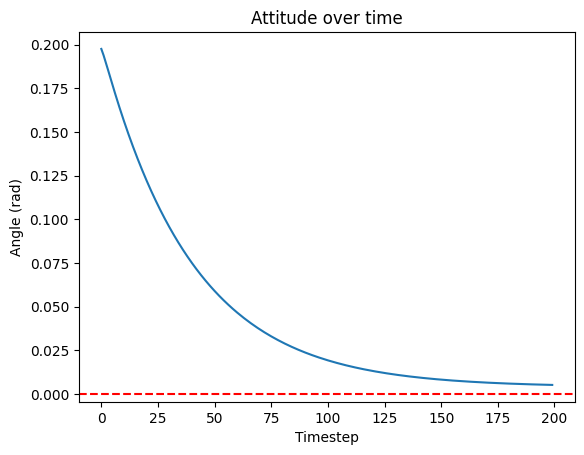

In [36]:
with torch.no_grad():
    gimbals, thetas = simulate(policy,
                               torch.tensor(0.2, device=device),
                               torch.tensor(0.0, device=device),
                               device)

plt.plot(thetas.cpu().numpy())
plt.axhline(0, color='r', linestyle='--')
plt.xlabel('Timestep')
plt.ylabel('Angle (rad)')
plt.title('Attitude over time')
plt.show()

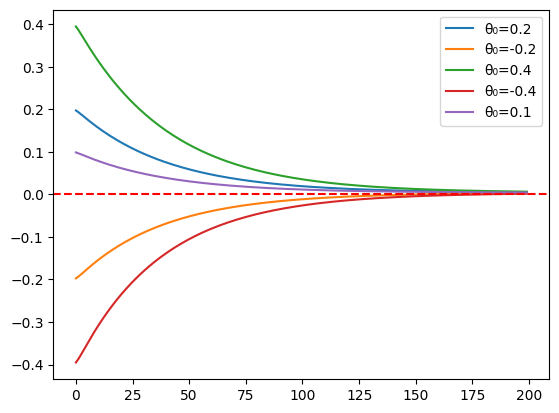

In [37]:
for theta_0 in [0.2, -0.2, 0.4, -0.4, 0.1]:
    with torch.no_grad():
        _, thetas = simulate(policy, 
                             torch.tensor(theta_0, device=device),
                             torch.tensor(0.0, device=device),
                             device)
    plt.plot(thetas.cpu().numpy(), label=f"θ₀={theta_0}")

plt.axhline(0, color='r', linestyle='--')
plt.legend()
plt.show()